# 01 · Análisis exploratorio

**Taller B5-T1 · Generación de datos financieros sinteticos**

El objetivo de este notebook es doble. Por un lado, caracterizar los datos con
el detalle suficiente para saber que debe reproducir un generador para que sus
muestras sean creibles. Por otro, cuantificar hasta que punto el problema
planteado sufre realmente de escasez de ejemplos, que es la premisa sobre la que
descansa todo el trabajo posterior.

El análisis se organiza en cuatro bloques: propiedades estadisticas de las
rentabilidades, estructura de dependencia entre activos, caracterización de la
variable objetivo y diagnostico de la dificultad del problema.

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\raulr\Documents\MIAX\Practicas\B5-T1


## 1. Reconstrucción de los datos

Se reconstruyen las rentabilidades limpias siguiendo exactamente los mismos
pasos del notebook anterior, y se carga el dataset ya procesado para disponer de
las particiones y de la etiqueta.

In [2]:
precios = datos.cargar_precios()
returns_bruto = datos.calcular_rentabilidades(precios)
returns, n_recortes = datos.limpiar_rentabilidades(returns_bruto)
ret_mercado = datos.serie_mercado(returns)

d = datos.cargar_dataset()
tickers = list(d["tickers"])

fechas_train = d["fechas_train"]
fechas_val = d["fechas_val"]
fechas_test = d["fechas_test"]

print(f"Activos: {len(tickers)}")
print(f"Sesiones de rentabilidad: {len(returns)}")
print(f"Ventanas: train {len(d['y_train'])}, validación {len(d['y_val'])}, "
      f"test {len(d['y_test'])}")
print(f"Umbral de drawdown: {100 * float(d['umbral_dd']):.2f} %")

Activos: 23
Sesiones de rentabilidad: 16270
Ventanas: train 11326, validación 2337, test 2337
Umbral de drawdown: -7.91 %


## 2. Propiedades de las rentabilidades diarias

### 2.1 Distribución marginal

La primera comprobación es si las rentabilidades se comportan como una variable
normal. La respuesta condiciona la elección de generadores: si la distribución
fuese aproximadamente gaussiana, un modelo basado en media y covarianza bastaria
y los modelos neuronales no aportarian nada.

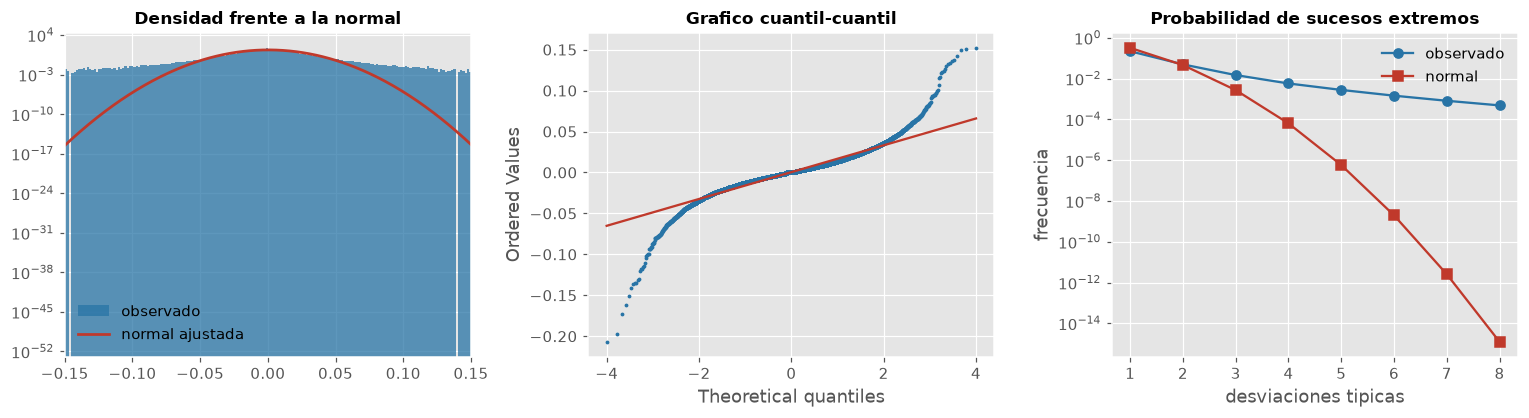

Asimetría: -0.183
Curtosis en exceso: 10.5  (una normal vale 0)
Sesiones que superan 5 sigmas: 1031
Esperadas bajo normalidad: 0.2


In [3]:
from scipy import stats

muestra = returns.values.ravel()
mu, sigma = muestra.mean(), muestra.std()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

rejilla = np.linspace(muestra.min(), muestra.max(), 500)
axes[0].hist(muestra, bins=300, density=True, color="#2874a6", alpha=0.75,
             label="observado")
axes[0].plot(rejilla, stats.norm.pdf(rejilla, mu, sigma), color="#c0392b",
             linewidth=1.8, label="normal ajustada")
axes[0].set_yscale("log")
axes[0].set_xlim(-0.15, 0.15)
axes[0].set_title("Densidad frente a la normal")
axes[0].legend()

stats.probplot(muestra[::17], dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markersize(1.5)
axes[1].get_lines()[0].set_color("#2874a6")
axes[1].get_lines()[1].set_color("#c0392b")
axes[1].set_title("Grafico cuantil-cuantil")

umbrales = np.arange(1, 9)
frec_empirica = [float((np.abs(muestra) > k * sigma).mean()) for k in umbrales]
frec_normal = [float(2 * stats.norm.sf(k)) for k in umbrales]
axes[2].plot(umbrales, frec_empirica, marker="o", color="#2874a6", label="observado")
axes[2].plot(umbrales, frec_normal, marker="s", color="#c0392b", label="normal")
axes[2].set_yscale("log")
axes[2].set_xlabel("desviaciones tipicas")
axes[2].set_ylabel("frecuencia")
axes[2].set_title("Probabilidad de sucesos extremos")
axes[2].legend()

fig.tight_layout()
graficos.guardar(fig, "01_distribucion_marginal")
plt.show()

print(f"Asimetría: {stats.skew(muestra):.3f}")
print(f"Curtosis en exceso: {stats.kurtosis(muestra):.1f}  (una normal vale 0)")
print(f"Sesiones que superan 5 sigmas: {int((np.abs(muestra) > 5 * sigma).sum())}")
print(f"Esperadas bajo normalidad: {2 * stats.norm.sf(5) * len(muestra):.1f}")

La distribución presenta colas considerablemente más pesadas que la normal. Los
movimientos que superan cinco desviaciones tipicas son varios ordenes de
magnitud más frecuentes de lo que predice el modelo gaussiano, y son justamente
esos movimientos los que componen los episodios que se pretende anticipar.

La consecuencia práctica es directa: un generador que solo replique la media y
la covarianza producira muestras demasiado benignas y apenas contendra los
escenarios de interés. Este es el motivo por el que el modelo de referencia
simple del taller debe interpretarse como un limite inferior de exigencia y no
como un competidor serio.

### 2.2 Estructura temporal

Las rentabilidades diarias son prácticamente incorreladas, pero sus valores
absolutos no lo son en absoluto: a un día de fuerte movimiento le sigue con alta
probabilidad otro día agitado. Este fenomeno, conocido como agrupamiento de
volatilidad, es la propiedad temporal que da sentido a observar una ventana de
sesenta días en lugar de un único dato.

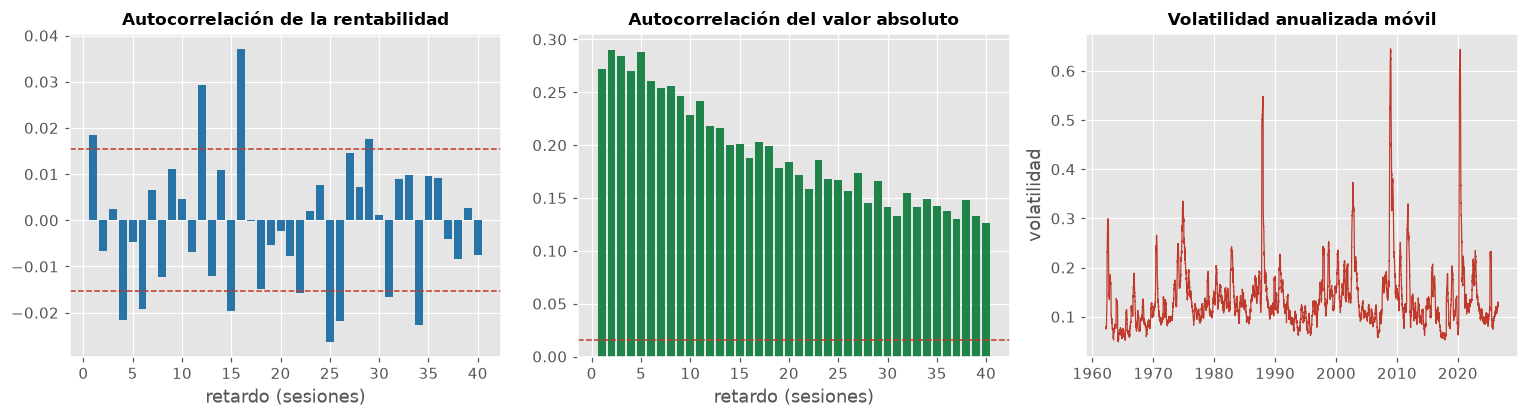

Autocorrelación de la rentabilidad en el retardo 1: 0.0185
Autocorrelación del valor absoluto en el retardo 1: 0.2722
Autocorrelación del valor absoluto en el retardo 20: 0.1841


In [4]:
def autocorrelaciones(serie, retardos):
    return [float(pd.Series(serie).autocorr(lag=k)) for k in retardos]

retardos = np.arange(1, 41)
acf_ret = autocorrelaciones(ret_mercado.values, retardos)
acf_abs = autocorrelaciones(np.abs(ret_mercado.values), retardos)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

banda = 1.96 / np.sqrt(len(ret_mercado))
axes[0].bar(retardos, acf_ret, color="#2874a6")
axes[0].axhline(banda, color="#c0392b", linestyle="--", linewidth=1)
axes[0].axhline(-banda, color="#c0392b", linestyle="--", linewidth=1)
axes[0].set_title("Autocorrelación de la rentabilidad")
axes[0].set_xlabel("retardo (sesiones)")

axes[1].bar(retardos, acf_abs, color="#1e8449")
axes[1].axhline(banda, color="#c0392b", linestyle="--", linewidth=1)
axes[1].set_title("Autocorrelación del valor absoluto")
axes[1].set_xlabel("retardo (sesiones)")

vol_anual = ret_mercado.rolling(60).std() * np.sqrt(252)
axes[2].plot(vol_anual.index, vol_anual.values, color="#c0392b", linewidth=0.8)
axes[2].set_title("Volatilidad anualizada móvil")
axes[2].set_ylabel("volatilidad")

fig.tight_layout()
graficos.guardar(fig, "01_estructura_temporal")
plt.show()

print(f"Autocorrelación de la rentabilidad en el retardo 1: {acf_ret[0]:.4f}")
print(f"Autocorrelación del valor absoluto en el retardo 1: {acf_abs[0]:.4f}")
print(f"Autocorrelación del valor absoluto en el retardo 20: {acf_abs[19]:.4f}")

La rentabilidad apenas guarda memoria de un día para otro, mientras que su
magnitud conserva dependencia significativa durante varias semanas. Un generador
que trate cada sesión de la ventana como independiente producira series
visualmente planas, sin la alternancia entre tramos tranquilos y tramos agitados
que caracteriza a una serie real.

## 3. Estructura de dependencia entre activos

### 3.1 Correlaciones y componentes principales

El drawdown se mide sobre la cartera equiponderada, de modo que lo que determina
la magnitud de una caída no es el comportamiento de un activo aislado sino el
grado en que todos se mueven a la vez. Reproducir correctamente esta estructura
de dependencia es el requisito más exigente para un generador.

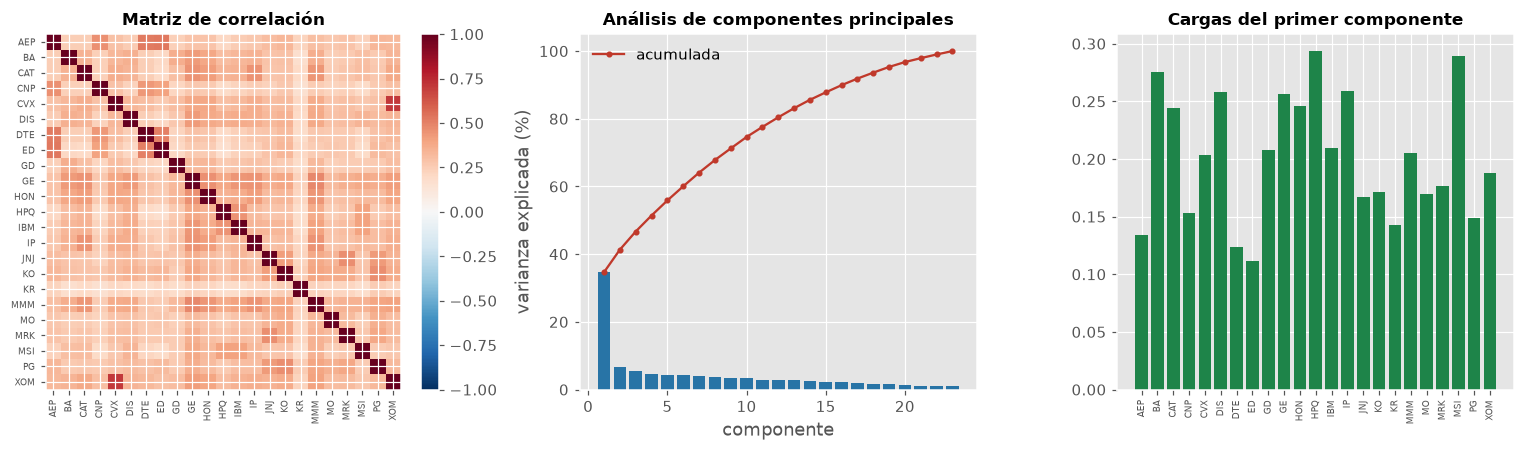

Correlación media entre pares distintos: 0.308
Varianza explicada por el primer componente: 34.7 %
Componentes necesarios para alcanzar el 80 %: 12


In [5]:
correlación = returns.corr()

fig = plt.figure(figsize=(14, 4.2))
ax0 = fig.add_subplot(1, 3, 1)
im = ax0.imshow(correlación.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax0.set_xticks(range(len(tickers)))
ax0.set_xticklabels(tickers, rotation=90, fontsize=6)
ax0.set_yticks(range(len(tickers)))
ax0.set_yticklabels(tickers, fontsize=6)
ax0.set_title("Matriz de correlación")
fig.colorbar(im, ax=ax0, fraction=0.046)

from sklearn.decomposition import PCA

pca = PCA().fit(returns.values)
varianza = pca.explained_variance_ratio_

ax1 = fig.add_subplot(1, 3, 2)
ax1.bar(range(1, len(varianza) + 1), 100 * varianza, color="#2874a6")
ax1.plot(range(1, len(varianza) + 1), 100 * np.cumsum(varianza), color="#c0392b",
         marker="o", markersize=3, label="acumulada")
ax1.set_xlabel("componente")
ax1.set_ylabel("varianza explicada (%)")
ax1.set_title("Análisis de componentes principales")
ax1.legend()

ax2 = fig.add_subplot(1, 3, 3)
ax2.bar(tickers, pca.components_[0], color="#1e8449")
ax2.tick_params(axis="x", rotation=90, labelsize=6)
ax2.set_title("Cargas del primer componente")

fig.tight_layout()
graficos.guardar(fig, "01_dependencia_activos")
plt.show()

print(f"Correlación media entre pares distintos: "
      f"{correlación.values[np.triu_indices(len(tickers), k=1)].mean():.3f}")
print(f"Varianza explicada por el primer componente: {100 * varianza[0]:.1f} %")
print(f"Componentes necesarios para alcanzar el 80 %: "
      f"{int(np.searchsorted(np.cumsum(varianza), 0.80) + 1)}")

El primer componente principal carga con signo homogeneo sobre prácticamente
todos los activos: representa el movimiento común del mercado y concentra por si
solo una fracción elevada de la varianza total. El resto de componentes recoge
diferencias sectoriales de magnitud mucho menor.

### 3.2 Correlación en función del régimen

La correlación media no es constante. Aumenta de forma acusada durante los
periodos de tensión, fenomeno que agrava las caídas porque anula el efecto de la
diversificación justo cuando resultaria más útil. Se contrasta a continuación la
correlación móvil con la volatilidad del mercado.

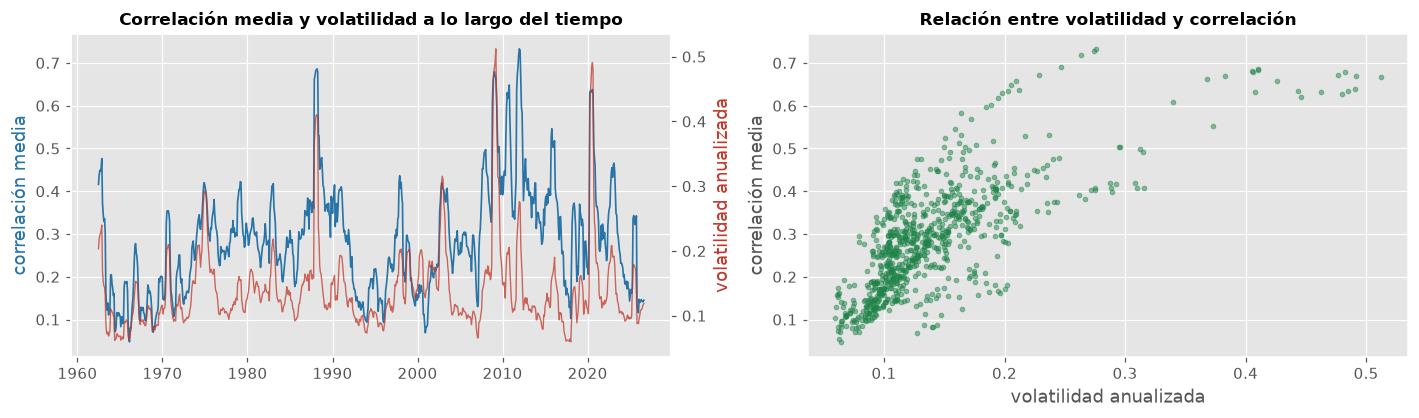

Correlación entre ambas magnitudes: 0.737


In [6]:
def correlacion_media_movil(df, ventana=120):
    valores = []
    índices = []
    paso = 20
    triangulo = np.triu_indices(df.shape[1], k=1)
    for i in range(ventana, len(df), paso):
        bloque = df.iloc[i - ventana:i]
        c = np.corrcoef(bloque.values.T)
        valores.append(float(c[triangulo].mean()))
        índices.append(df.index[i])
    return pd.Series(valores, index=índices)

corr_movil = correlacion_media_movil(returns)
vol_movil = (ret_mercado.rolling(120).std() * np.sqrt(252)).reindex(corr_movil.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))

ax_izq = axes[0]
ax_izq.plot(corr_movil.index, corr_movil.values, color="#2874a6", linewidth=1.1,
            label="correlación media")
ax_izq.set_ylabel("correlación media", color="#2874a6")
ax_der = ax_izq.twinx()
ax_der.plot(vol_movil.index, vol_movil.values, color="#c0392b", linewidth=0.9,
            alpha=0.75, label="volatilidad")
ax_der.set_ylabel("volatilidad anualizada", color="#c0392b")
ax_der.grid(False)
ax_izq.set_title("Correlación media y volatilidad a lo largo del tiempo")

axes[1].scatter(vol_movil.values, corr_movil.values, s=10, alpha=0.5, color="#1e8449")
axes[1].set_xlabel("volatilidad anualizada")
axes[1].set_ylabel("correlación media")
axes[1].set_title("Relación entre volatilidad y correlación")

fig.tight_layout()
graficos.guardar(fig, "01_correlacion_regimen")
plt.show()

valido = vol_movil.notna() & corr_movil.notna()
print(f"Correlación entre ambas magnitudes: "
      f"{np.corrcoef(vol_movil[valido], corr_movil[valido])[0, 1]:.3f}")

La relación es claramente positiva: los periodos de mayor volatilidad son
también los de mayor sincronia entre activos. Un generador que produjese
ventanas con una correlación fija, igual a la media histórica, sería incapaz de
representar el régimen que precede a los episodios de estrés.

## 4. Caracterización de la variable objetivo

### 4.1 Que distingue a una ventana positiva

Se comparan las ventanas etiquetadas como positivas y negativas mediante un
conjunto de descriptores calculados sobre la propia ventana de entrada. El
interés no es construir esos descriptores como caracteristicas del modelo, sino
comprobar si existe señal aprovechable y de que naturaleza es.

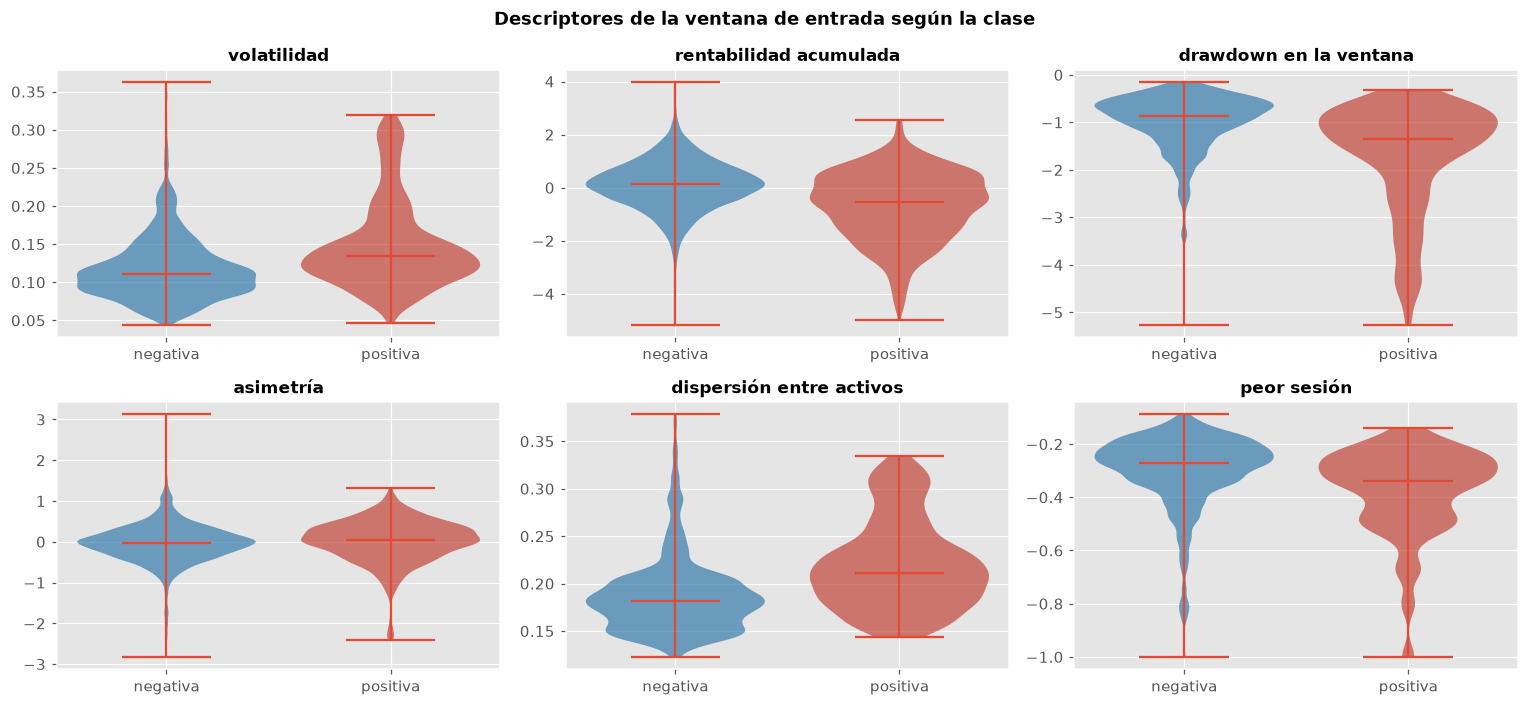

clase,negativa,positiva,diferencia relativa
volatilidad,0.1182,0.1492,0.2629
rentabilidad acumulada,0.0956,-0.6931,-8.2497
drawdown en la ventana,-1.0163,-1.7301,-0.7023
asimetría,-0.0419,0.0071,1.1687
dispersión entre activos,0.1878,0.2202,0.1724
peor sesión,-0.3013,-0.3822,-0.2685


In [7]:
X_train = d["X_train"]
y_train = d["y_train"]

def descriptores(X):
    ret_cartera = X.mean(axis=2)
    acumulada = ret_cartera.sum(axis=1)
    trayectoria = np.cumsum(ret_cartera, axis=1)
    maximo_movil = np.maximum.accumulate(trayectoria, axis=1)
    return pd.DataFrame({
        "volatilidad": ret_cartera.std(axis=1),
        "rentabilidad acumulada": acumulada,
        "drawdown en la ventana": (trayectoria - maximo_movil).min(axis=1),
        "asimetría": pd.DataFrame(ret_cartera).skew(axis=1).values,
        "dispersión entre activos": X.std(axis=2).mean(axis=1),
        "peor sesión": ret_cartera.min(axis=1),
    })

desc = descriptores(X_train)
desc["clase"] = np.where(y_train == 1, "positiva", "negativa")

fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for ax, columna in zip(axes.ravel(), desc.columns[:-1]):
    grupos = [desc.loc[desc["clase"] == c, columna].values for c in ("negativa", "positiva")]
    partes = ax.violinplot(grupos, showmedians=True, widths=0.8)
    for cuerpo, color in zip(partes["bodies"], ["#2874a6", "#c0392b"]):
        cuerpo.set_facecolor(color)
        cuerpo.set_alpha(0.65)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["negativa", "positiva"])
    ax.set_title(columna)

fig.suptitle("Descriptores de la ventana de entrada según la clase", fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "01_descriptores_por_clase")
plt.show()

resumen_desc = desc.groupby("clase").mean().T
resumen_desc["diferencia relativa"] = (
    (resumen_desc["positiva"] - resumen_desc["negativa"]) / resumen_desc["negativa"].abs()
)
display(resumen_desc.round(4))

Las ventanas que preceden a una caída severa presentan mayor volatilidad y mayor
dispersión entre activos, pero las distribuciones se solapan de forma
considerable. No existe ningún descriptor que separe las clases por si solo, lo
que confirma que el problema es genuinamente difícil y que la señal, de haberla,
reside en combinaciones del patron temporal completo.

### 4.2 Separabilidad en el espacio de entrada

Se proyectan las ventanas sobre sus dos primeros componentes principales para
observar la disposición de ambas clases.

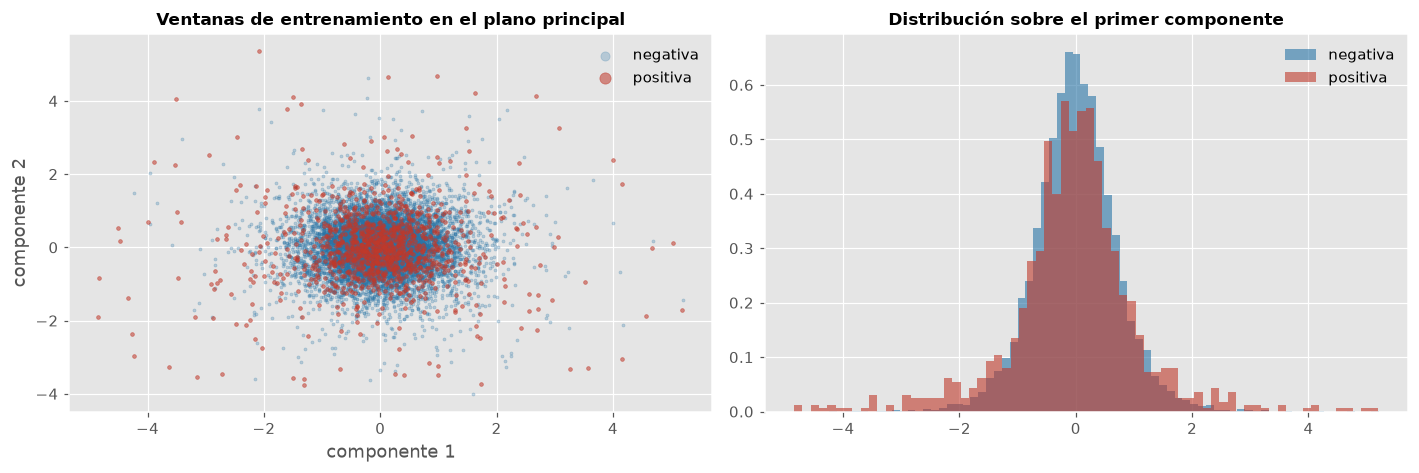

In [8]:
X_plano = X_train.reshape(len(X_train), -1)
proyección = PCA(n_components=2, random_state=config.SEMILLA).fit_transform(X_plano)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

negativos = y_train == 0
axes[0].scatter(proyección[negativos, 0], proyección[negativos, 1], s=4, alpha=0.25,
                color="#2874a6", label="negativa")
axes[0].scatter(proyección[~negativos, 0], proyección[~negativos, 1], s=6, alpha=0.55,
                color="#c0392b", label="positiva")
axes[0].set_title("Ventanas de entrenamiento en el plano principal")
axes[0].set_xlabel("componente 1")
axes[0].set_ylabel("componente 2")
axes[0].legend(markerscale=3)

axes[1].hist(proyección[negativos, 0], bins=70, density=True, alpha=0.6,
             color="#2874a6", label="negativa")
axes[1].hist(proyección[~negativos, 0], bins=70, density=True, alpha=0.6,
             color="#c0392b", label="positiva")
axes[1].set_title("Distribución sobre el primer componente")
axes[1].legend()

fig.tight_layout()
graficos.guardar(fig, "01_separabilidad_pca")
plt.show()

Ambas clases ocupan la misma región del espacio y solo se aprecia un ligero
desplazamiento de las positivas hacia valores más dispersos del primer
componente. La frontera de decisión, en caso de existir, no es lineal ni queda
capturada por las direcciones de máxima varianza.

## 5. Diagnostico de la escasez

### 5.1 El recuento de positivos es enganoso

El conjunto de entrenamiento contiene más de un millar de ventanas positivas,
cifra que en apariencia no indica escasez. Sin embargo, esas ventanas no son
observaciones independientes: dado que ventanas consecutivas comparten
prácticamente toda su información, un único episodio de crisis genera decenas de
positivos casi identicos.

El recuento relevante no es el número de ventanas positivas sino el número de
**episodios distintos**, entendiendo por tal cada racha ininterrumpida de
etiquetas positivas. Es esta cifra la que determina cuanta variedad real de
escenarios de estrés ha podido observar el modelo.

Ventanas positivas en entrenamiento: 1137
Episodios independientes de estrés:  51
Duración mediana de un episodio:     18 sesiones
Ventanas positivas por episodio:     22.3


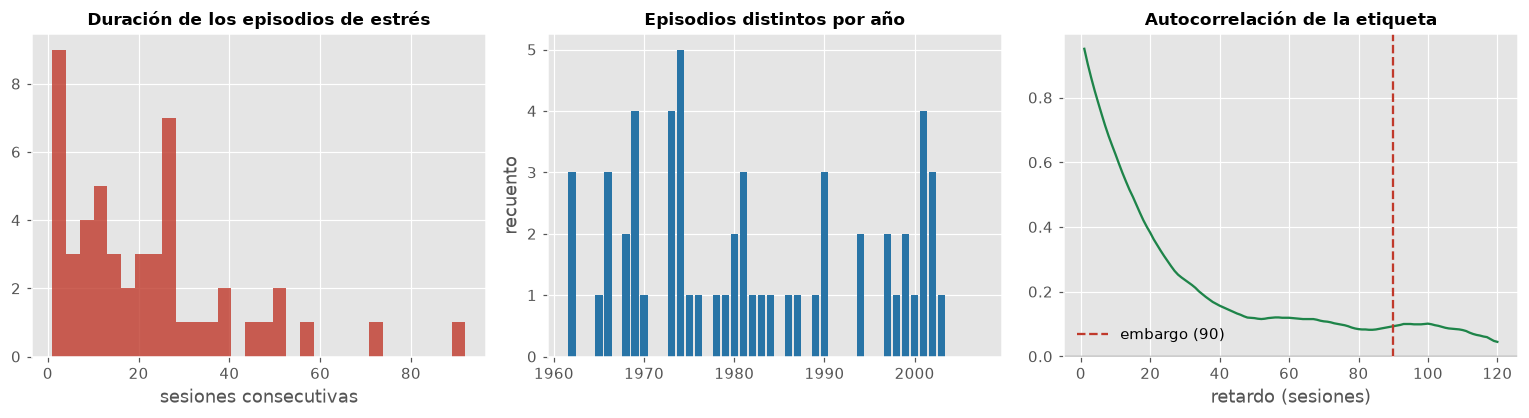

In [9]:
def contar_episodios(y):
    cambios = np.diff(np.concatenate([[0], (y == 1).astype(int), [0]]))
    inicios = np.where(cambios == 1)[0]
    finales = np.where(cambios == -1)[0]
    return inicios, finales, finales - inicios

inicios, finales, longitudes = contar_episodios(y_train)

print(f"Ventanas positivas en entrenamiento: {int(y_train.sum())}")
print(f"Episodios independientes de estrés:  {len(longitudes)}")
print(f"Duración mediana de un episodio:     {int(np.median(longitudes))} sesiones")
print(f"Ventanas positivas por episodio:     {y_train.sum() / len(longitudes):.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

axes[0].hist(longitudes, bins=30, color="#c0392b", alpha=0.8)
axes[0].set_title("Duración de los episodios de estrés")
axes[0].set_xlabel("sesiones consecutivas")

serie_etiqueta = pd.Series(y_train, index=fechas_train)
episodios_anuales = serie_etiqueta.groupby(serie_etiqueta.index.year).apply(
    lambda s: len(contar_episodios(s.values)[2]))
axes[1].bar(episodios_anuales.index, episodios_anuales.values, color="#2874a6")
axes[1].set_title("Episodios distintos por año")
axes[1].set_ylabel("recuento")

acf_etiqueta = [float(pd.Series(y_train).autocorr(lag=k)) for k in range(1, 121)]
axes[2].plot(range(1, 121), acf_etiqueta, color="#1e8449")
axes[2].axhline(0, color="#2c2c2c", linewidth=0.8)
axes[2].axvline(config.EMBARGO, color="#c0392b", linestyle="--",
                label=f"embargo ({config.EMBARGO})")
axes[2].set_title("Autocorrelación de la etiqueta")
axes[2].set_xlabel("retardo (sesiones)")
axes[2].legend()

fig.tight_layout()
graficos.guardar(fig, "01_episodios_estres")
plt.show()

El resultado sostiene la premisa del trabajo. Frente a un millar largo de
ventanas positivas, el número de episodios verdaderamente distintos es de apenas
unas decenas repartidas en cuatro decadas y media. Cada uno de ellos aporta una
sola configuración de mercado, replicada despues en muchas ventanas solapadas.

De ahi se derivan dos consecuencias:

- El modelo dispone de muy pocos ejemplos genuinamente distintos de la situación
  que debe reconocer, y corre el riesgo de memorizar la forma concreta de unas
  pocas crisis en lugar de aprender el patron general.
- La autocorrelación de la etiqueta se mantiene alta durante más de cien
  sesiones, lo que confirma la necesidad del embargo aplicado en la partición:
  sin el, ventanas del mismo episodio apareceran simultáneamente en
  entrenamiento y en test.

Un modelo generativo capaz de producir configuraciones de mercado plausibles y
distintas entre si compensaria precisamente esta carencia. Esa es la hipotesis
que el resto del proyecto pone a prueba.

### 5.2 Cobertura temporal de los episodios

Se representa por último la localización de los episodios positivos sobre la
serie del mercado, distinguiendo las tres particiones.

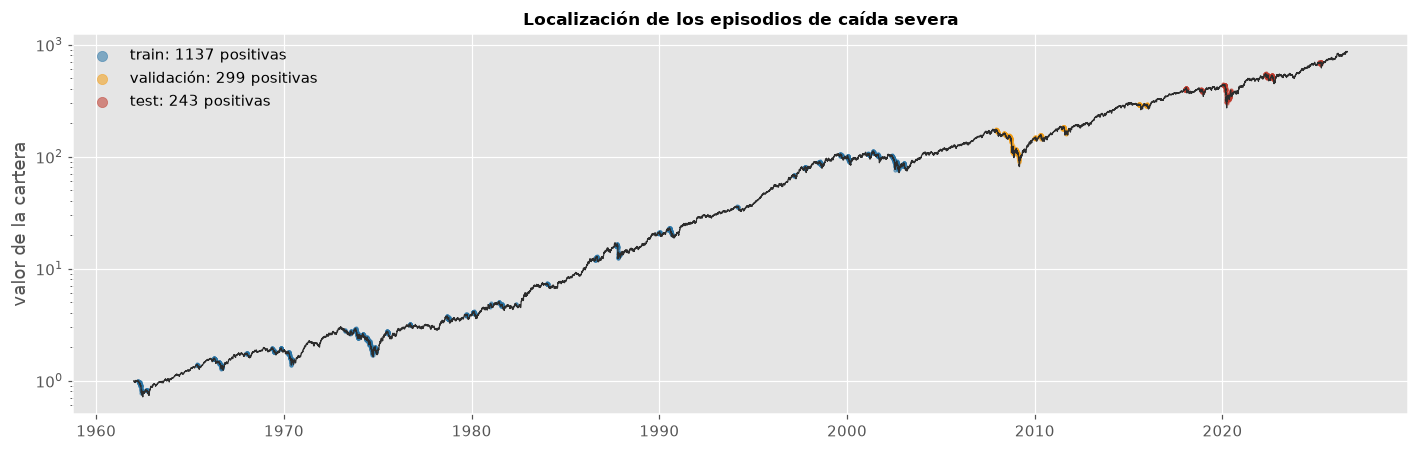

train         1137 ventanas positivas en  51 episodios distintos
validación     299 ventanas positivas en  10 episodios distintos
test           243 ventanas positivas en   8 episodios distintos


In [10]:
fig, ax = plt.subplots(figsize=(13, 4.2))

valor = np.exp(ret_mercado.cumsum())
ax.plot(valor.index, valor.values, color="#2c2c2c", linewidth=0.8)
ax.set_yscale("log")

for nombre, fechas_p, y_p, color in [
    ("train", fechas_train, d["y_train"], "#2874a6"),
    ("validación", fechas_val, d["y_val"], "#f39c12"),
    ("test", fechas_test, d["y_test"], "#c0392b"),
]:
    positivas = fechas_p[y_p == 1]
    ax.scatter(positivas, valor.reindex(positivas, method="nearest").values,
               s=5, alpha=0.55, color=color, label=f"{nombre}: {int(y_p.sum())} positivas")

ax.set_title("Localización de los episodios de caída severa")
ax.set_ylabel("valor de la cartera")
ax.legend(markerscale=3)
fig.tight_layout()
graficos.guardar(fig, "01_episodios_en_el_tiempo")
plt.show()

for nombre, y_p in [("train", d["y_train"]), ("validación", d["y_val"]), ("test", d["y_test"])]:
    _, _, longs = contar_episodios(y_p)
    print(f"{nombre:<12s} {int(y_p.sum()):>5d} ventanas positivas en "
          f"{len(longs):>3d} episodios distintos")

## Conclusiones del notebook

El análisis deja establecidos los siguientes puntos, que orientan el diseño de
los generadores y la lectura de los resultados:

1. **Las rentabilidades no son gaussianas.** Presentan colas notablemente más
   pesadas y una curtosis muy elevada. Un generador limitado a media y
   covarianza no producira los escenarios extremos que interesan.
2. **La volatilidad se agrupa en el tiempo.** Las ventanas reales alternan
   tramos tranquilos y agitados, y un generador que trate las sesiones como
   independientes producira series reconociblemente artificiales.
3. **La dependencia entre activos varia con el régimen.** La correlación media
   aumenta en los periodos de tensión, de modo que la estructura de covarianza no
   puede considerarse constante.
4. **Las clases se solapan de forma acusada.** Ningún descriptor sencillo las
   separa y la proyección principal no revela frontera alguna, lo que anticipa
   metricas modestas en terminos absolutos.
5. **La escasez es real aunque no lo parezca.** El millar largo de ventanas
   positivas se reduce a unas pocas decenas de episodios independientes, y es
   ese número el que limita lo que el modelo puede aprender.

Los criterios de evaluación de cualquier generador quedan por tanto fijados:
debe reproducir las colas, el agrupamiento de volatilidad y la estructura de
correlación, y debe producir escenarios de estrés variados en lugar de copias de
los pocos que contiene el histórico.